**Let's explore bifurcation of time independent NLSE in one dimension without potential (all dimensionless)**

See *NLSE.ipynb* in *Quantum Mechanics* folder

New feature: better early stopping mechanism using 'deque' from collections

In [1]:
# Importing libraries
import numpy as np
from scipy.linalg import eigh_tridiagonal
from scipy.integrate import trapezoid

from collections import deque

import matplotlib.pyplot as plt
plt.style.use('classic') # Classic style

In [2]:
def plot_xmax_vs_g(state, g_values, N = 300, max_iter = 500, min_iter = 150, patience = 50, tol = 1e-12):
    
    """
    Compute and plot the position of the maximum of the wavefunction and the
    corresponding eigenvalue (energy) versus the nonlinear coupling constant g
    for a given eigenstate of the 1D nonlinear dimensionless Schrödinger equation.

    The problem is discretized on a uniform grid with N interior points and
    solved by self-consistent iteration using the tridiagonal eigensolver for
    the state selected by index `state`. Early stopping is applied based on
    the relative variation of the eigenvalue over a moving window.

    Parameters
    ----------
    state : int
        Index of the eigenstate to track (0 = ground state, 1 = first excited, ...).
    g_values : array_like
        Array of coupling constants g to scan
    N : int, optional
        Number of interior grid points.
    max_iter : int, optional
        Maximum number of self-consistent iterations per g.
    min_iter : int, optional
        Minimum iterations before early stopping is allowed.
    patience : int, optional
        Size of the moving window for convergence check.
    tol : float, optional
        Relative tolerance for convergence.

    Returns None
    -------
    Displays a figure with two panels:
        - Left: x_max vs g
        - Right: energy vs g
    """

    # Spatial grid
    x = np.linspace(0, 1, N + 2)
    h = x[1] - x[0]
    x_int = x[1:-1]  # interior points

    # Elements of the tridiagonal Laplacian matrix
    d = np.full(N, 2.0)
    e = np.full(N - 1, -1.0)

    # Linear solution used as initial guess (same for all g values)
    psi_linear = eigh_tridiagonal(d, e, select = 'i', select_range = (state, state))[1]
    psi_linear = psi_linear.reshape(-1)
    psi_linear /= np.sqrt(trapezoid(psi_linear ** 2, x_int))

    xmax_list = []   # positions of the maximum
    energy_list = [] # energies

    for g in g_values:
        psi = psi_linear.copy()
        energy_window = deque(maxlen = patience)  # moving window for energy values

        for it in range(max_iter):
            # Build nonlinear potential: V_nonlin = g * h^2 * psi^2
            V_nonlin = g * (h ** 2) * (psi ** 2)
            # Solve the eigenvalue problem for the desired state
            w, psi_new = eigh_tridiagonal(d + V_nonlin, e, select = 'i', select_range = (state, state))
            psi_new = psi_new.reshape(-1)
            # Normalize the new wavefunction
            psi_new /= np.sqrt(trapezoid(psi_new ** 2, x_int))
            psi = psi_new

            eigenvalue = w[0]
            energy = eigenvalue / (h ** 2)

            # ----- Early stopping mechanism -----
            if it >= min_iter:                # past the mandatory phase
                energy_window.append(energy)
                if len(energy_window) == patience:
                    # Compute relative variation within the window
                    e_min = min(energy_window)
                    e_max = max(energy_window)
                    e_mean = np.mean(energy_window)
                    if (e_max - e_min) < tol * abs(e_mean):
                        # Convergence reached: exit loop
                        break
            # -----------------------------------

        # Save energy and position of the maximum (from last iteration)
        energy_list.append(energy)
        idx_max = np.argmax(np.abs(psi))
        xmax_list.append(x_int[idx_max])

    # Create figure with two side-by-side panels
    _, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 6))

    # Left panel: position of the maximum vs g
    ax1.scatter(xmax_list, g_values, s = 4, color = 'black')
    ax1.set_xlabel(r'$x_{\mathrm{max}}$', fontsize = 14)
    ax1.set_ylabel(r"$g$", fontsize = 14)
    ax1.set_title(f"Position of the maximum vs $g$ (state {state})", fontsize = 14)
    ax1.grid(True, alpha = 0.75)

    # Right panel: energy vs g
    ax2.scatter(g_values, energy_list, s = 4, color = 'green')
    ax2.set_xlabel(r"$g$", fontsize = 14)
    ax2.set_ylabel(r'$E$', fontsize = 14)
    ax2.set_title(f"Energy vs $g$ (state {state})", fontsize = 14)
    ax2.grid(True, alpha = 0.75)

    plt.tight_layout()
    plt.show()

    return None

In [3]:
# Some parameters
ng = 1_000
g_positive = np.linspace(0.0, 300.0, ng)
g_negative = np.linspace(- 300.0, 0.0, ng)

ground_state = 0
first_state = 1
second_state = 2

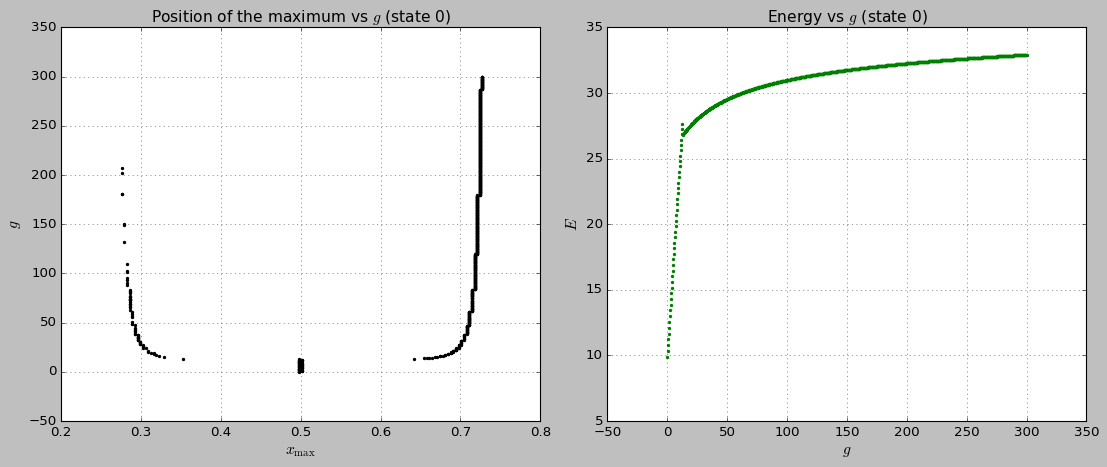

In [4]:
plot_xmax_vs_g(state = ground_state, g_values = g_positive)

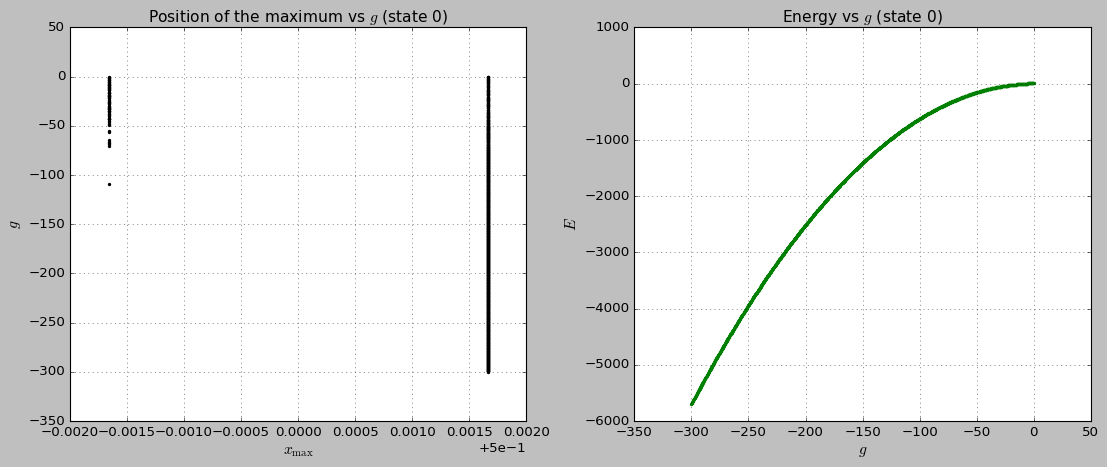

In [5]:
plot_xmax_vs_g(state = ground_state, g_values = g_negative)

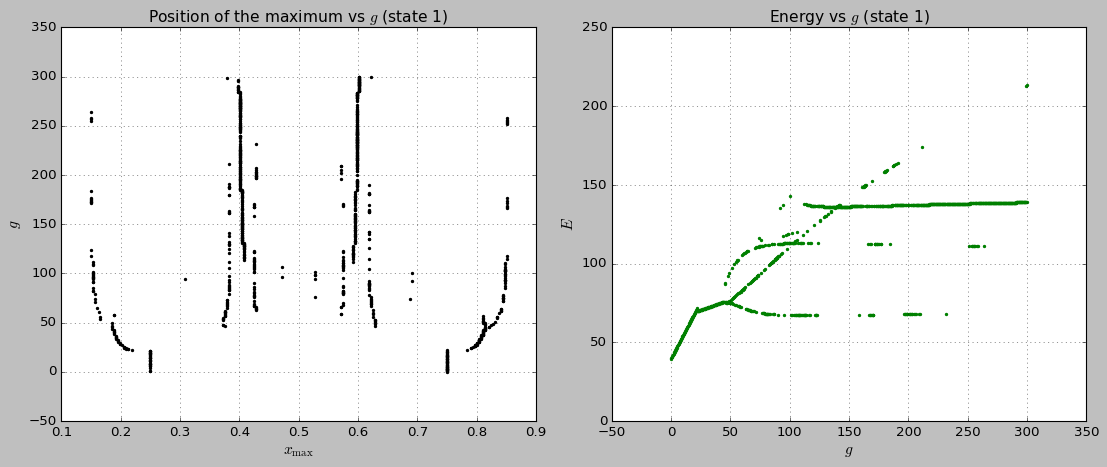

In [6]:
plot_xmax_vs_g(state = first_state, g_values = g_positive)

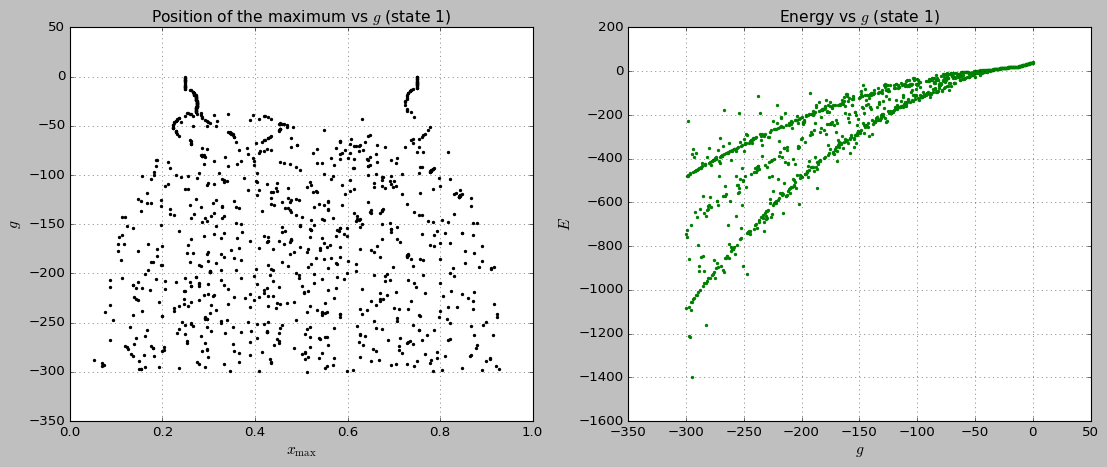

In [7]:
plot_xmax_vs_g(state = first_state, g_values = g_negative)

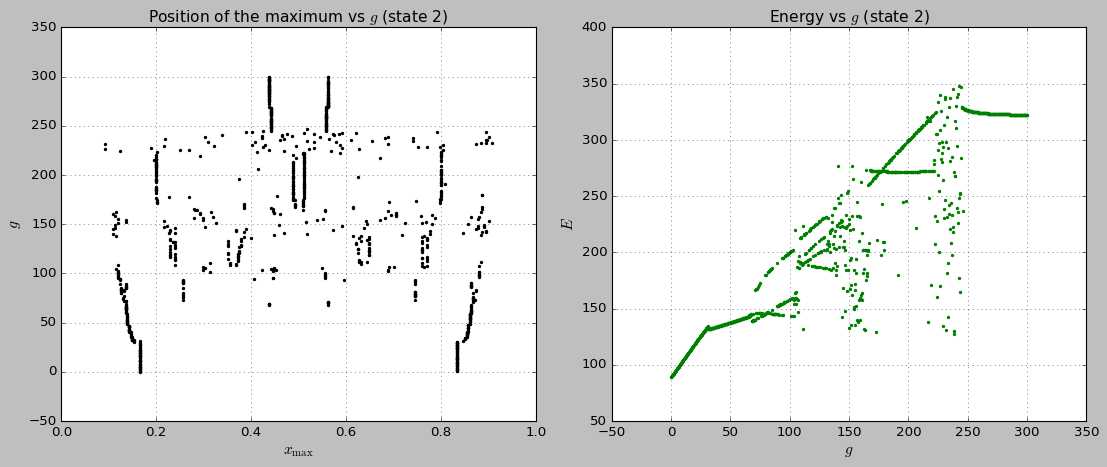

In [8]:
plot_xmax_vs_g(state = second_state, g_values = g_positive)

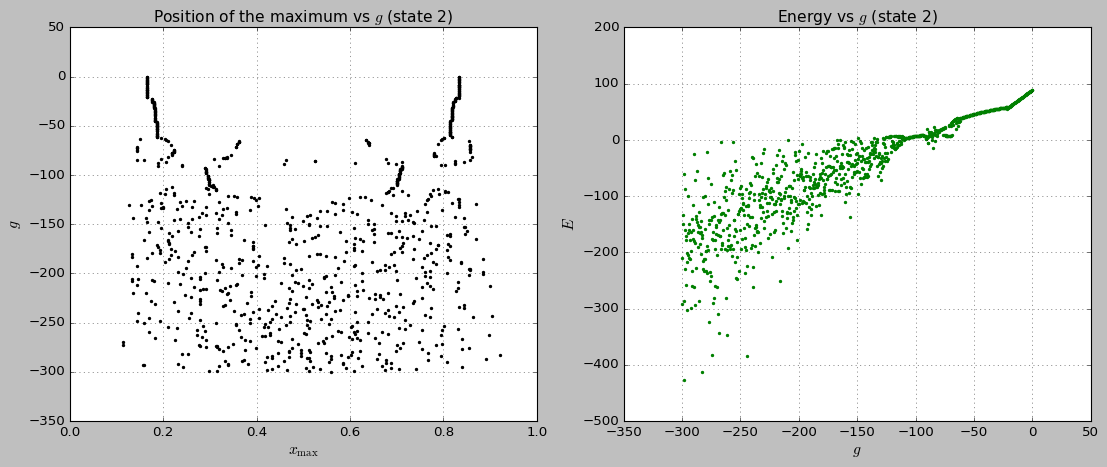

In [9]:
plot_xmax_vs_g(state = second_state, g_values = g_negative)